<a href="https://colab.research.google.com/github/bharat3645/pbl/blob/main/DL_Image_Encryption_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Deep Learning-based Image Encryption System

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, Input
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from tqdm import tqdm
import cv2
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
from scipy.stats import entropy

In [ ]:
# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
# Checking if GPU is available
print("GPU Available: ", tf.config.list_physical_devices('GPU'))


GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# PART 1: DCGAN FOR KEY GENERATION
# ===============================

In [ ]:
class DCGAN:
    def __init__(self, img_size=64, latent_dim=100):
        self.img_size = img_size
        self.latent_dim = latent_dim
        self.img_shape = (img_size, img_size, 3)

        # Build and compile the discriminator
        self.discriminator = self.build_discriminator()
        self.discriminator.compile(loss='binary_crossentropy',
                                  optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
                                  metrics=['accuracy'])

        # Build the generator
        self.generator = self.build_generator()

        # The combined model (stacked generator and discriminator)
        self.discriminator.trainable = False
        z_input = Input(shape=(self.latent_dim,))
        img = self.generator(z_input)
        valid = self.discriminator(img)
        self.combined = models.Model(z_input, valid)
        self.combined.compile(loss='binary_crossentropy',
                             optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

    def build_generator(self):
        # Use the Functional API
        noise_input = Input(shape=(self.latent_dim,))

        # Foundation for 4x4 image with more filters for better feature generation
        x = layers.Dense(4*4*1024, activation='relu')(noise_input)
        x = layers.Reshape((4, 4, 1024))(x)

        # Add batch normalization and leaky ReLU for better training stability
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)

        # Upsampling layers with residual connections
        # First upsampling: 4x4 -> 8x8
        x = layers.Conv2DTranspose(512, (5, 5), strides=(2, 2), padding='same')(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)

        # Second upsampling: 8x8 -> 16x16
        x = layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same')(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)

        # Third upsampling: 16x16 -> 32x32
        x = layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same')(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)

        # Fourth upsampling: 32x32 -> 64x64
        x = layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same')(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)

        # Add a final fine-grained refinement layer
        x = layers.Conv2D(64, (3, 3), padding='same')(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)

        # Output layer with tanh activation for pixel values in [-1, 1]
        x = layers.Conv2D(3, (3, 3), padding='same', activation='tanh')(x)

        model = models.Model(noise_input, x, name='generator')
        model.summary()

        return model

    def build_discriminator(self):
        # Use the Functional API
        img_input = Input(shape=self.img_shape)

        x = layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same')(img_input)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Conv2D(512, (5, 5), strides=(2, 2), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(negative_slope=0.2)(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Flatten()(x)
        x = layers.Dense(1, activation='sigmoid')(x)

        model = models.Model(img_input, x, name='discriminator')
        model.summary()

        return model

    def train(self, dataset, epochs, batch_size=128, save_interval=50):
        # Create folder for saving generated images
        os.makedirs('generated_images', exist_ok=True)

        half_batch = batch_size // 2

        d_losses = []
        g_losses = []

        for epoch in range(epochs):
            # Select a random half batch of images
            idx = np.random.randint(0, dataset.shape[0], half_batch)
            imgs = dataset[idx]

            # Sample noise and generate a half batch of new images
            noise = np.random.normal(0, 1, (half_batch, self.latent_dim))
            gen_imgs = self.generator.predict(noise)

            # Train the discriminator
            d_loss_real = self.discriminator.train_on_batch(imgs, np.ones((half_batch, 1)))
            d_loss_fake = self.discriminator.train_on_batch(gen_imgs, np.zeros((half_batch, 1)))
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            # Train the generator
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            g_loss = self.combined.train_on_batch(noise, np.ones((batch_size, 1)))

            d_losses.append(d_loss[0])
            g_losses.append(g_loss)

            # Print the progress and plot generated images
            if epoch % save_interval == 0:
                print(f"{epoch}/{epochs} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")
                self.save_imgs(epoch)
                self.plot_loss(d_losses, g_losses)

        # Save models after training
        self.generator.save('generator_model.keras')
        self.discriminator.save('discriminator_model.keras')

        # Make sure we return the losses
        return d_losses, g_losses

    def save_imgs(self, epoch):
        r, c = 3, 3
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator.predict(noise)

        # Rescale images 0 - 1
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(r, c, figsize=(15, 15))
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i,j].imshow(gen_imgs[cnt])
                axs[i,j].axis('off')
                cnt += 1
        plt.savefig(f"generated_images/gan_image_epoch_{epoch}.png")
        plt.close()

    def plot_loss(self, d_losses, g_losses):
        plt.figure(figsize=(10, 5))
        plt.plot(d_losses, label='Discriminator')
        plt.plot(g_losses, label='Generator')
        plt.title('Training Losses')
        plt.legend()
        plt.savefig('loss_plot.png')
        plt.close()

    def generate_keys(self, n_keys=1):
        """Generate keys using the trained generator"""
        noise = np.random.normal(0, 1, (n_keys, self.latent_dim))
        keys = self.generator.predict(noise)
        # Normalize to [0, 1] range
        keys = 0.5 * keys + 0.5
        return keys

# PART 2: ENCRYPTION NETWORK
# =========================


In [ ]:
class EncryptionNetwork:
    def __init__(self, img_size=64):
        self.img_size = img_size
        self.img_shape = (img_size, img_size, 3)

        # Build encryption and decryption models
        self.encryption_model = self.build_encryption_model()
        self.decryption_model = self.build_decryption_model()

    def build_encryption_model(self):
        # Input layers
        img_input = Input(shape=self.img_shape)
        key_input = Input(shape=self.img_shape)

        # Image processing with consistent dimensions
        x1 = layers.Conv2D(64, (3, 3), padding='same')(img_input)
        x1 = layers.LeakyReLU(negative_slope=0.2)(x1)

        x2 = layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same')(x1)
        x2 = layers.BatchNormalization()(x2)
        x2 = layers.LeakyReLU(negative_slope=0.2)(x2)

        # Key processing with matching dimensions
        k1 = layers.Conv2D(64, (3, 3), padding='same')(key_input)
        k1 = layers.LeakyReLU(negative_slope=0.2)(k1)

        k2 = layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same')(k1)
        k2 = layers.BatchNormalization()(k2)
        k2 = layers.LeakyReLU(negative_slope=0.2)(k2)

        # Now x2 and k2 have the same shape (None, 32, 32, 128)
        merged = layers.Concatenate()([x2, k2])
        # merged shape: (None, 32, 32, 256)

        # Self-attention on the merged features
        attention = layers.Conv2D(256, (1, 1), padding='same')(merged)
        attention = layers.LeakyReLU(negative_slope=0.2)(attention)
        attention = layers.Conv2D(256, (1, 1), padding='same', activation='sigmoid')(attention)

        # Continue processing with deeper network
        y = layers.Conv2D(256, (3, 3), strides=(2, 2), padding='same')(merged)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 16, 16, 256)

        # Make sure attention matches y's shape for multiplication
        attention_resized = layers.Conv2D(256, (3, 3), strides=(2, 2), padding='same')(attention)

        # Apply attention
        y = layers.Multiply()([y, attention_resized])

        y = layers.Conv2D(512, (3, 3), strides=(2, 2), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 8, 8, 512)

        # Add residual block for better feature preservation
        res = layers.Conv2D(512, (3, 3), padding='same')(y)
        res = layers.BatchNormalization()(res)
        res = layers.LeakyReLU(negative_slope=0.2)(res)
        res = layers.Conv2D(512, (3, 3), padding='same')(res)
        res = layers.BatchNormalization()(res)
        y = layers.Add()([y, res])
        y = layers.LeakyReLU(negative_slope=0.2)(y)

        # Upsampling with skip connections for better information flow
        y = layers.Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 16, 16, 256)

        y = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 32, 32, 128)

        # Store intermediate merged features for skip connection
        merged_features = merged
        # Add skip connection with proper shape matching
        y = layers.Concatenate()([y, merged_features])

        y = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 64, 64, 64)

        # Add skip connection with upsampled x1
        y = layers.Concatenate()([y, x1])

        # Output layer with tanh activation to limit values between -1 and 1
        encrypted_img = layers.Conv2D(3, (3, 3), padding='same', activation='tanh')(y)

        return models.Model([img_input, key_input], encrypted_img, name='encryption_model')

    def build_decryption_model(self):
        # Input layers
        encrypted_img_input = Input(shape=self.img_shape)
        key_input = Input(shape=self.img_shape)

        # Similar architecture as encryption but with matching dimensions
        x1 = layers.Conv2D(64, (3, 3), padding='same')(encrypted_img_input)
        x1 = layers.LeakyReLU(negative_slope=0.2)(x1)

        x2 = layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same')(x1)
        x2 = layers.BatchNormalization()(x2)
        x2 = layers.LeakyReLU(negative_slope=0.2)(x2)

        # Key processing with matching dimensions
        k1 = layers.Conv2D(64, (3, 3), padding='same')(key_input)
        k1 = layers.LeakyReLU(negative_slope=0.2)(k1)

        k2 = layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same')(k1)
        k2 = layers.BatchNormalization()(k2)
        k2 = layers.LeakyReLU(negative_slope=0.2)(k2)

        # Now x2 and k2 have the same shape (None, 32, 32, 128)
        merged = layers.Concatenate()([x2, k2])
        # merged shape: (None, 32, 32, 256)

        # Self-attention on the merged features
        attention = layers.Conv2D(256, (1, 1), padding='same')(merged)
        attention = layers.LeakyReLU(negative_slope=0.2)(attention)
        attention = layers.Conv2D(256, (1, 1), padding='same', activation='sigmoid')(attention)

        # Continue processing with deeper network
        y = layers.Conv2D(256, (3, 3), strides=(2, 2), padding='same')(merged)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 16, 16, 256)

        # Make sure attention matches y's shape for multiplication
        attention_resized = layers.Conv2D(256, (3, 3), strides=(2, 2), padding='same')(attention)

        # Apply attention
        y = layers.Multiply()([y, attention_resized])

        y = layers.Conv2D(512, (3, 3), strides=(2, 2), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 8, 8, 512)

        # Add residual block
        res = layers.Conv2D(512, (3, 3), padding='same')(y)
        res = layers.BatchNormalization()(res)
        res = layers.LeakyReLU(negative_slope=0.2)(res)
        res = layers.Conv2D(512, (3, 3), padding='same')(res)
        res = layers.BatchNormalization()(res)
        y = layers.Add()([y, res])
        y = layers.LeakyReLU(negative_slope=0.2)(y)

        # Upsampling with skip connections
        y = layers.Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 16, 16, 256)

        y = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 32, 32, 128)

        # Store intermediate merged features for skip connection
        merged_features = merged
        # Add skip connection with proper shape matching
        y = layers.Concatenate()([y, merged_features])

        y = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(y)
        y = layers.BatchNormalization()(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        # y shape: (None, 64, 64, 64)

        # Add skip connection with upsampled x1
        y = layers.Concatenate()([y, x1])

        # Output layer
        y = layers.Conv2D(64, (3, 3), padding='same')(y)
        y = layers.LeakyReLU(negative_slope=0.2)(y)
        decrypted_img = layers.Conv2D(3, (3, 3), padding='same', activation='tanh')(y)

        return models.Model([encrypted_img_input, key_input], decrypted_img, name='decryption_model')

    def compile_models(self):
        # Compile encryption model with improved optimizer settings
        self.encryption_model.compile(
            loss='mse',
            optimizer=optimizers.Adam(learning_rate=0.0001, beta_1=0.5)
        )

        # Compile decryption model
        self.decryption_model.compile(
            loss='mse',
            optimizer=optimizers.Adam(learning_rate=0.0001, beta_1=0.5)
        )

        # Combined model for end-to-end training with perceptual loss component
        img_input = Input(shape=self.img_shape)
        key_input = Input(shape=self.img_shape)

        encrypted_img = self.encryption_model([img_input, key_input])
        decrypted_img = self.decryption_model([encrypted_img, key_input])

        self.combined_model = models.Model([img_input, key_input], decrypted_img)

        # Use a custom loss function that includes both MSE and entropy components
        self.combined_model.compile(
            loss='mse',  # Base loss is MSE
            optimizer=optimizers.Adam(learning_rate=0.0001, beta_1=0.5)
        )

    def train(self, images, keys, epochs=100, batch_size=32, sample_interval=10):
        os.makedirs('encryption_samples', exist_ok=True)
        os.makedirs('model_checkpoints', exist_ok=True)

        # Rescale images to [-1, 1]
        images_scaled = images * 2.0 - 1.0
        keys_scaled = keys * 2.0 - 1.0

        # Arrays to store loss values
        combined_losses = []

        # Prepare validation data
        val_indices = np.random.choice(images.shape[0], 4, replace=False)
        val_images = images_scaled[val_indices]
        val_keys = keys_scaled[val_indices]

        # Implement learning rate scheduling
        initial_lr = 0.0001

        # Early stopping parameters
        best_loss = float('inf')
        patience = 10
        patience_counter = 0

        for epoch in range(epochs):
            # Learning rate decay
            if epoch > 0 and epoch % 20 == 0:
                new_lr = initial_lr * (0.5 ** (epoch // 20))
                self.combined_model.optimizer.learning_rate.assign(new_lr)
                print(f"Learning rate adjusted to {new_lr}")

            # Select a random batch of images and keys
            idx = np.random.randint(0, images.shape[0], batch_size)
            batch_images = images_scaled[idx]
            batch_keys = keys_scaled[idx]

            # Train the combined model
            combined_loss = self.combined_model.train_on_batch([batch_images, batch_keys], batch_images)
            combined_losses.append(combined_loss)

            # Print progress
            print(f"Epoch {epoch}/{epochs} - Combined Loss: {combined_loss:.4f}")

            # Generate samples at specified intervals
            if epoch % sample_interval == 0:
                self.sample_images(val_images, val_keys, epoch)
                self.plot_loss(combined_losses)

                # Save model checkpoint
                if combined_loss < best_loss:
                    best_loss = combined_loss
                    patience_counter = 0
                    self.encryption_model.save('model_checkpoints/best_encryption_model.keras')
                    self.decryption_model.save('model_checkpoints/best_decryption_model.keras')
                    print(f"New best model saved with loss: {best_loss:.6f}")
                else:
                    patience_counter += 1

                # Early stopping check
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch+1} epochs")
                    break

        # Save models with optimizer state
        self.encryption_model.save('encryption_model.keras', include_optimizer=True)
        self.decryption_model.save('decryption_model.keras', include_optimizer=True)

        return combined_losses


    def sample_images(self, images, keys, epoch):
        r, c = 2, 4  # Rows and columns for display

        # Process validation images
        encrypted_imgs = self.encryption_model.predict([images, keys])
        decrypted_imgs = self.decryption_model.predict([encrypted_imgs, keys])

        # Rescale to 0-1 for display
        images = (images + 1) / 2
        encrypted_imgs = (encrypted_imgs + 1) / 2
        decrypted_imgs = (decrypted_imgs + 1) / 2

        # Create a figure for display
        plt.figure(figsize=(15, 6))

        titles = ['Original', 'Encrypted', 'Decrypted', 'Encryption Key']

        for i in range(c):
            if i >= len(images):
                break

            # Original image
            plt.subplot(r, c, i+1)
            plt.title(titles[0])
            plt.imshow(images[i])
            plt.axis('off')

            # Encrypted image
            plt.subplot(r, c, i+1+c)
            plt.title(titles[1])
            plt.imshow(encrypted_imgs[i])
            plt.axis('off')

        plt.savefig(f"encryption_samples/sample_epoch_{epoch}.png")
        plt.close()

        # Create an additional figure showing decryption
        plt.figure(figsize=(15, 6))

        for i in range(c):
            if i >= len(images):
                break

            # Encrypted image
            plt.subplot(r, c, i+1)
            plt.title(titles[1])
            plt.imshow(encrypted_imgs[i])
            plt.axis('off')

            # Decrypted image
            plt.subplot(r, c, i+1+c)
            plt.title(titles[2])
            plt.imshow(decrypted_imgs[i])
            plt.axis('off')

        plt.savefig(f"encryption_samples/decryption_epoch_{epoch}.png")
        plt.close()

        # Third figure showing the encryption keys
        plt.figure(figsize=(15, 3))

        for i in range(c):
            if i >= len(keys):
                break

            # Encryption key
            plt.subplot(1, c, i+1)
            plt.title(titles[3])
            plt.imshow((keys[i] + 1) / 2)  # Rescale from [-1,1] to [0,1]
            plt.axis('off')

        plt.savefig(f"encryption_samples/keys_epoch_{epoch}.png")
        plt.close()

    def plot_loss(self, losses):
        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.savefig('encryption_loss_plot.png')
        plt.close()

    def encrypt(self, image, key):
        """Encrypt a single image using the provided key"""
        # Ensure inputs have the right shape
        if len(image.shape) == 3:
            image = np.expand_dims(image, axis=0)
        if len(key.shape) == 3:
            key = np.expand_dims(key, axis=0)

        # Scale to [-1, 1] range for model
        image_scaled = image * 2.0 - 1.0
        key_scaled = key * 2.0 - 1.0

        # Encrypt the image
        encrypted = self.encryption_model.predict([image_scaled, key_scaled])

        # Scale back to [0, 1] range
        encrypted = (encrypted + 1.0) / 2.0

        return encrypted[0]  # Return the first (and only) image

    def decrypt(self, encrypted_image, key):
        """Decrypt a single encrypted image using the provided key"""
        # Ensure inputs have the right shape
        if len(encrypted_image.shape) == 3:
            encrypted_image = np.expand_dims(encrypted_image, axis=0)
        if len(key.shape) == 3:
            key = np.expand_dims(key, axis=0)

        # Scale to [-1, 1] range for model
        encrypted_scaled = encrypted_image * 2.0 - 1.0
        key_scaled = key * 2.0 - 1.0

        # Decrypt the image
        decrypted = self.decryption_model.predict([encrypted_scaled, key_scaled])

        # Scale back to [0, 1] range
        decrypted = (decrypted + 1.0) / 2.0

        return decrypted[0]  # Return the first (and only) image



# PART 3: SECURITY ANALYSIS FUNCTIONS
# ==================================


In [ ]:
def compute_histogram(image):
    """Compute histogram for RGB channels"""
    hist_r = np.histogram(image[:,:,0].flatten(), bins=256, range=(0,1))[0]
    hist_g = np.histogram(image[:,:,1].flatten(), bins=256, range=(0,1))[0]
    hist_b = np.histogram(image[:,:,2].flatten(), bins=256, range=(0,1))[0]

    return hist_r, hist_g, hist_b

def compute_robust_ssim(img1, img2, data_range=1.0):
    """Computes SSIM with proper error handling for small images"""
    h, w, c = img1.shape

    # Determine the appropriate window size based on image dimensions
    win_size = min(7, min(h, w) - 1)
    if win_size % 2 == 0:
        win_size -= 1

    if win_size < 3:
        # If image is too small for SSIM calculation, fall back to MSE
        mse = np.mean((img1 - img2) ** 2)
        # Convert MSE to a pseudo-SSIM value (1 = perfect, 0 = bad)
        return 1 - min(1, mse * 10)

    # Calculate SSIM with the appropriate window size
    return ssim(img1, img2, data_range=data_range, channel_axis=2, win_size=win_size)

def plot_histograms(original, encrypted, decrypted):
    """Plot histograms for original, encrypted and decrypted images"""
    hist_orig_r, hist_orig_g, hist_orig_b = compute_histogram(original)
    hist_enc_r, hist_enc_g, hist_enc_b = compute_histogram(encrypted)
    hist_dec_r, hist_dec_g, hist_dec_b = compute_histogram(decrypted)

    plt.figure(figsize=(15, 10))

    # Red channel histograms
    plt.subplot(3, 3, 1)
    plt.title('Original Image (Red Channel)')
    plt.bar(range(256), hist_orig_r, color='red', alpha=0.7)

    plt.subplot(3, 3, 2)
    plt.title('Encrypted Image (Red Channel)')
    plt.bar(range(256), hist_enc_r, color='red', alpha=0.7)

    plt.subplot(3, 3, 3)
    plt.title('Decrypted Image (Red Channel)')
    plt.bar(range(256), hist_dec_r, color='red', alpha=0.7)

    # Green channel histograms
    plt.subplot(3, 3, 4)
    plt.title('Original Image (Green Channel)')
    plt.bar(range(256), hist_orig_g, color='green', alpha=0.7)

    plt.subplot(3, 3, 5)
    plt.title('Encrypted Image (Green Channel)')
    plt.bar(range(256), hist_enc_g, color='green', alpha=0.7)

    plt.subplot(3, 3, 6)
    plt.title('Decrypted Image (Green Channel)')
    plt.bar(range(256), hist_dec_g, color='green', alpha=0.7)

    # Blue channel histograms
    plt.subplot(3, 3, 7)
    plt.title('Original Image (Blue Channel)')
    plt.bar(range(256), hist_orig_b, color='blue', alpha=0.7)

    plt.subplot(3, 3, 8)
    plt.title('Encrypted Image (Blue Channel)')
    plt.bar(range(256), hist_enc_b, color='blue', alpha=0.7)

    plt.subplot(3, 3, 9)
    plt.title('Decrypted Image (Blue Channel)')
    plt.bar(range(256), hist_dec_b, color='blue', alpha=0.7)

    plt.tight_layout()
    plt.savefig('histogram_analysis.png')
    plt.close()

def compute_correlation(image, n_samples=1000):
    """Compute correlation coefficients of adjacent pixels"""
    h, w, c = image.shape
    x = np.zeros(n_samples)
    y_h = np.zeros(n_samples)  # horizontal
    y_v = np.zeros(n_samples)  # vertical
    y_d = np.zeros(n_samples)  # diagonal

    for channel in range(c):
        # Select random points
        i_points = np.random.randint(0, h-1, n_samples)
        j_points = np.random.randint(0, w-1, n_samples)

        # Get pixel values
        x = image[i_points, j_points, channel]
        y_h = image[i_points, j_points+1, channel]  # horizontal
        y_v = image[i_points+1, j_points, channel]  # vertical
        y_d = image[i_points+1, j_points+1, channel]  # diagonal

        # Compute correlation coefficients
        corr_h = np.corrcoef(x, y_h)[0, 1]
        corr_v = np.corrcoef(x, y_v)[0, 1]
        corr_d = np.corrcoef(x, y_d)[0, 1]

        return corr_h, corr_v, corr_d

def plot_correlation_scatter(image, n_samples=1000):
    """Create scatter plots for horizontal, vertical and diagonal correlations"""
    h, w, c = image.shape
    # Use red channel for visualization
    channel = 0

    # Select random points
    i_points = np.random.randint(0, h-1, n_samples)
    j_points = np.random.randint(0, w-1, n_samples)

    # Get pixel values
    x = image[i_points, j_points, channel]
    y_h = image[i_points, j_points+1, channel]  # horizontal
    y_v = image[i_points+1, j_points, channel]  # vertical
    y_d = image[i_points+1, j_points+1, channel]  # diagonal

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title('Horizontal Correlation')
    plt.scatter(x, y_h, s=1, alpha=0.5)
    plt.xlabel('Pixel Value')
    plt.ylabel('Adjacent Pixel Value')

    plt.subplot(1, 3, 2)
    plt.title('Vertical Correlation')
    plt.scatter(x, y_v, s=1, alpha=0.5)
    plt.xlabel('Pixel Value')
    plt.ylabel('Adjacent Pixel Value')

    plt.subplot(1, 3, 3)
    plt.title('Diagonal Correlation')
    plt.scatter(x, y_d, s=1, alpha=0.5)
    plt.xlabel('Pixel Value')
    plt.ylabel('Adjacent Pixel Value')

    plt.tight_layout()
    plt.savefig('correlation_scatter.png')
    plt.close()

def compute_information_entropy(image):
    """Compute information entropy for each channel"""
    h, w, c = image.shape
    entropy_values = []

    for channel in range(c):
        # Compute histogram
        hist, _ = np.histogram(image[:,:,channel].flatten(), bins=256, range=(0,1), density=True)
        hist = hist / np.sum(hist)  # Normalize

        # Remove zero probabilities
        hist = hist[hist > 0]

        # Compute entropy
        ent = -np.sum(hist * np.log2(hist))
        entropy_values.append(ent)

    return entropy_values

def compute_npcr_uaci(img1, img2):
    """
    Compute Number of Pixels Change Rate (NPCR) and Unified Average Changing Intensity (UACI)
    """
    # Normalize to [0, 255] for calculations
    img1_255 = np.round(img1 * 255).astype(np.uint8)
    img2_255 = np.round(img2 * 255).astype(np.uint8)

    # Create a matrix D where D[i,j]=0 if img1[i,j]=img2[i,j] and 1 otherwise
    D = np.zeros_like(img1_255, dtype=np.uint8)
    D[img1_255 != img2_255] = 1

    # NPCR calculation
    npcr = np.sum(D) / D.size * 100

    # UACI calculation
    uaci = np.sum(np.abs(img1_255.astype(np.float32) - img2_255.astype(np.float32)) / 255) / D.size * 100

    return npcr, uaci



def security_analysis(original_image, encrypted_image, decrypted_image, wrong_key_decrypted=None):
    """Run comprehensive security analysis on the encryption system with improved metrics"""
    # Create a results directory
    os.makedirs('security_analysis', exist_ok=True)

    # 1. Image visual comparison
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(original_image)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Encrypted Image')
    plt.imshow(encrypted_image)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Decrypted Image')
    plt.imshow(decrypted_image)
    plt.axis('off')

    plt.savefig('security_analysis/visual_comparison.png')
    plt.close()

    if wrong_key_decrypted is not None:
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.title('Correct Key Decryption')
        plt.imshow(decrypted_image)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Wrong Key Decryption')
        plt.imshow(wrong_key_decrypted)
        plt.axis('off')

        plt.savefig('security_analysis/key_sensitivity.png')
        plt.close()

    # 2. Histogram analysis
    plot_histograms(original_image, encrypted_image, decrypted_image)

    # 3. Correlation coefficient analysis
    corr_orig_h, corr_orig_v, corr_orig_d = compute_correlation(original_image)
    corr_enc_h, corr_enc_v, corr_enc_d = compute_correlation(encrypted_image)
    corr_dec_h, corr_dec_v, corr_dec_d = compute_correlation(decrypted_image)

    print("Correlation Coefficients:")
    print(f"Original: Horizontal={corr_orig_h:.4f}, Vertical={corr_orig_v:.4f}, Diagonal={corr_orig_d:.4f}")
    print(f"Encrypted: Horizontal={corr_enc_h:.4f}, Vertical={corr_enc_v:.4f}, Diagonal={corr_enc_d:.4f}")
    print(f"Decrypted: Horizontal={corr_dec_h:.4f}, Vertical={corr_dec_v:.4f}, Diagonal={corr_dec_d:.4f}")

    # Plot correlation scatter plots
    plot_correlation_scatter(original_image, title='Original Image Correlation')
    plot_correlation_scatter(encrypted_image, title='Encrypted Image Correlation')

    # 4. Information entropy analysis
    entropy_orig = compute_information_entropy(original_image)
    entropy_enc = compute_information_entropy(encrypted_image)
    entropy_dec = compute_information_entropy(decrypted_image)

    print("\nInformation Entropy:")
    print(f"Original: R={entropy_orig[0]:.4f}, G={entropy_orig[1]:.4f}, B={entropy_orig[2]:.4f}")
    print(f"Encrypted: R={entropy_enc[0]:.4f}, G={entropy_enc[1]:.4f}, B={entropy_enc[2]:.4f}")
    print(f"Decrypted: R={entropy_dec[0]:.4f}, G={entropy_dec[1]:.4f}, B={entropy_dec[2]:.4f}")

    # 5. Quality assessment
    mse_dec = mean_squared_error(original_image.flatten(), decrypted_image.flatten())
    psnr_dec = 10 * np.log10((1.0**2) / mse_dec) if mse_dec > 0 else 100  # Using max value of 1.0
    ssim_dec = ssim(original_image, decrypted_image, data_range=1.0, channel_axis=2, win_size=3)

    print("\nQuality Assessment:")
    print(f"MSE between original and decrypted: {mse_dec:.6f}")
    print(f"PSNR between original and decrypted: {psnr_dec:.2f} dB")
    print(f"SSIM between original and decrypted: {ssim_dec:.6f}")

    # 6. Differential attack analysis - NPCR and UACI
    if wrong_key_decrypted is not None:
        # Between correct decryption and wrong key decryption
        npcr_key, uaci_key = compute_npcr_uaci(decrypted_image, wrong_key_decrypted)

        # Between original and encrypted
        npcr_enc, uaci_enc = compute_npcr_uaci(original_image, encrypted_image)

        print("\nDifferential Attack Analysis:")
        print(f"Between original and encrypted:")
        print(f"NPCR: {npcr_enc:.2f}% (ideal: ~99.6%)")
        print(f"UACI: {uaci_enc:.2f}% (ideal: ~33.4%)")

        print(f"\nBetween correct and wrong key decryption:")
        print(f"NPCR: {npcr_key:.2f}% (ideal: ~99.6%)")
        print(f"UACI: {uaci_key:.2f}% (ideal: ~33.4%)")

    # 7. Save all results to a text file
    with open('security_analysis/results.txt', 'w') as f:
        f.write("Deep Learning Image Encryption Security Analysis\n")
        f.write("==============================================\n\n")

        f.write("Correlation Coefficients:\n")
        f.write(f"Original: Horizontal={corr_orig_h:.4f}, Vertical={corr_orig_v:.4f}, Diagonal={corr_orig_d:.4f}\n")
        f.write(f"Encrypted: Horizontal={corr_enc_h:.4f}, Vertical={corr_enc_v:.4f}, Diagonal={corr_enc_d:.4f}\n")
        f.write(f"Decrypted: Horizontal={corr_dec_h:.4f}, Vertical={corr_dec_v:.4f}, Diagonal={corr_dec_d:.4f}\n\n")

        f.write("Information Entropy:\n")
        f.write(f"Original: R={entropy_orig[0]:.4f}, G={entropy_orig[1]:.4f}, B={entropy_orig[2]:.4f}\n")
        f.write(f"Encrypted: R={entropy_enc[0]:.4f}, G={entropy_enc[1]:.4f}, B={entropy_enc[2]:.4f}\n")
        f.write(f"Decrypted: R={entropy_dec[0]:.4f}, G={entropy_dec[1]:.4f}, B={entropy_dec[2]:.4f}\n\n")

        f.write("Quality Assessment:\n")
        f.write(f"MSE between original and decrypted: {mse_dec:.6f}\n")
        f.write(f"PSNR between original and decrypted: {psnr_dec:.2f} dB\n")
        f.write(f"SSIM between original and decrypted: {ssim_dec:.6f}\n\n")

        if wrong_key_decrypted is not None:
            f.write("Differential Attack Analysis:\n")
            f.write(f"Between original and encrypted:\n")
            f.write(f"NPCR: {npcr_enc:.2f}% (ideal: ~99.6%)\n")
            f.write(f"UACI: {uaci_enc:.2f}% (ideal: ~33.4%)\n\n")

            f.write(f"Between correct and wrong key decryption:\n")
            f.write(f"NPCR: {npcr_key:.2f}% (ideal: ~99.6%)\n")
            f.write(f"UACI: {uaci_key:.2f}% (ideal: ~33.4%)\n")

    # 8. Plot additional visualizations for increased interpretability
    # Visualization of the difference between original and encrypted
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(original_image)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Encrypted Image')
    plt.imshow(encrypted_image)
    plt.axis('off')

    # Calculate difference and scale for visibility
    diff = np.abs(original_image - encrypted_image)
    diff = diff / np.max(diff) if np.max(diff) > 0 else diff

    plt.subplot(1, 3, 3)
    plt.title('Difference (Enhanced)')
    plt.imshow(diff)
    plt.axis('off')

    plt.savefig('security_analysis/encryption_difference.png')
    plt.close()

    # Return a summary of key security metrics
    return {
        'mse': mse_dec,
        'psnr': psnr_dec,
        'ssim': ssim_dec,
        'entropy_enc': np.mean(entropy_enc),
        'correlation_enc': np.mean([corr_enc_h, corr_enc_v, corr_enc_d])
    }

# Enhanced correlation scatter plot
def plot_correlation_scatter(image, n_samples=1000, title='Correlation Analysis'):
    h, w, c = image.shape
    # Use red channel for visualization
    channel = 0

    # Select random points
    i_points = np.random.randint(0, h-1, n_samples)
    j_points = np.random.randint(0, w-1, n_samples)

    # Get pixel values
    x = image[i_points, j_points, channel]
    y_h = image[i_points, j_points+1, channel]  # horizontal
    y_v = image[i_points+1, j_points, channel]  # vertical
    y_d = image[i_points+1, j_points+1, channel]  # diagonal

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title('Horizontal Correlation')
    plt.scatter(x, y_h, s=1, alpha=0.5, c='red')
    plt.xlabel('Pixel Value')
    plt.ylabel('Adjacent Pixel Value')
    corr_h = np.corrcoef(x, y_h)[0, 1]
    plt.text(0.05, 0.95, f'Corr: {corr_h:.4f}', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8))

    plt.subplot(1, 3, 2)
    plt.title('Vertical Correlation')
    plt.scatter(x, y_v, s=1, alpha=0.5, c='green')
    plt.xlabel('Pixel Value')
    plt.ylabel('Adjacent Pixel Value')
    corr_v = np.corrcoef(x, y_v)[0, 1]
    plt.text(0.05, 0.95, f'Corr: {corr_v:.4f}', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8))

    plt.subplot(1, 3, 3)
    plt.title('Diagonal Correlation')
    plt.scatter(x, y_d, s=1, alpha=0.5, c='blue')
    plt.xlabel('Pixel Value')
    plt.ylabel('Adjacent Pixel Value')
    corr_d = np.corrcoef(x, y_d)[0, 1]
    plt.text(0.05, 0.95, f'Corr: {corr_d:.4f}', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8))

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f'security_analysis/{title.lower().replace(" ", "_")}.png')
    plt.close()

def add_noise_to_image(image, noise_level=0.1):
    """Add random noise to an image for robustness testing"""
    noise = np.random.normal(0, noise_level, image.shape)
    noisy_image = image + noise
    # Clip to valid range [0, 1]
    return np.clip(noisy_image, 0, 1)

def apply_random_transformation(image):
    """Apply a random transformation to test robustness"""
    h, w, c = image.shape

    # Choose a random transformation
    transform_type = np.random.choice(['rotate', 'crop', 'flip', 'blur'])

    if transform_type == 'rotate':
        # Random rotation between -30 and 30 degrees
        angle = np.random.uniform(-30, 30)
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
        transformed = cv2.warpAffine(image, M, (w, h))

    elif transform_type == 'crop':
        # Random crop and resize back
        crop_percent = np.random.uniform(0.8, 0.9)
        crop_size = int(min(h, w) * crop_percent)
        start_h = np.random.randint(0, h - crop_size + 1)
        start_w = np.random.randint(0, w - crop_size + 1)
        crop = image[start_h:start_h+crop_size, start_w:start_w+crop_size]
        transformed = cv2.resize(crop, (w, h))

    elif transform_type == 'flip':
        # Horizontal flip
        transformed = cv2.flip(image, 1)

    elif transform_type == 'blur':
        # Apply slight blur
        transformed = cv2.GaussianBlur(image, (3, 3), 0)

    return transformed

def test_encryption_robustness(encryption_net, image, key, transformations=True, noise=True):
    """Test the robustness of the encryption system against transformations and noise"""
    results = []

    # Original encryption and decryption
    encrypted_orig = encryption_net.encrypt(image, key)
    decrypted_orig = encryption_net.decrypt(encrypted_orig, key)

    results.append({
        'type': 'original',
        'encrypted': encrypted_orig,
        'decrypted': decrypted_orig,
        'mse': mean_squared_error(image.flatten(), decrypted_orig.flatten()),
        'ssim': compute_robust_ssim(image, decrypted_orig)
    })

    if noise:
        # Test with noisy image
        noisy_image = add_noise_to_image(image, 0.05)
        encrypted_noisy = encryption_net.encrypt(noisy_image, key)
        decrypted_noisy = encryption_net.decrypt(encrypted_noisy, key)

        results.append({
            'type': 'noisy_input',
            'encrypted': encrypted_noisy,
            'decrypted': decrypted_noisy,
            'mse': mean_squared_error(image.flatten(), decrypted_noisy.flatten()),
            'ssim': compute_robust_ssim(image, decrypted_noisy)
        })

        # Test with noisy encryption
        encrypted_orig_noisy = add_noise_to_image(encrypted_orig, 0.05)
        decrypted_noisy_enc = encryption_net.decrypt(encrypted_orig_noisy, key)

        results.append({
            'type': 'noisy_encryption',
            'encrypted': encrypted_orig_noisy,
            'decrypted': decrypted_noisy_enc,
            'mse': mean_squared_error(image.flatten(), decrypted_noisy_enc.flatten()),
            'ssim': compute_robust_ssim(image, decrypted_noisy_enc)
        })

    if transformations:
        # Test with transformed image
        transformed_image = apply_random_transformation(image)
        encrypted_transformed = encryption_net.encrypt(transformed_image, key)
        decrypted_transformed = encryption_net.decrypt(encrypted_transformed, key)

        results.append({
            'type': 'transformed_input',
            'encrypted': encrypted_transformed,
            'decrypted': decrypted_transformed,
            'mse': mean_squared_error(transformed_image.flatten(), decrypted_transformed.flatten()),
            'ssim': compute_robust_ssim(transformed_image, decrypted_transformed)
        })

    # Visualize the results
    plt.figure(figsize=(15, 10))
    for i, result in enumerate(results):
        # Original/Input image
        if i == 0:  # Original
            input_img = image
        elif result['type'] == 'noisy_input':
            input_img = add_noise_to_image(image, 0.05)
        elif result['type'] == 'transformed_input':
            input_img = apply_random_transformation(image)
        else:
            input_img = image

        plt.subplot(len(results), 3, i*3 + 1)
        plt.title(f"Input ({result['type']})")
        plt.imshow(input_img)
        plt.axis('off')

        # Encrypted image
        plt.subplot(len(results), 3, i*3 + 2)
        plt.title(f"Encrypted ({result['type']})")
        plt.imshow(result['encrypted'])
        plt.axis('off')

        # Decrypted image
        plt.subplot(len(results), 3, i*3 + 3)
        plt.title(f"Decrypted (MSE: {result['mse']:.4f}, SSIM: {result['ssim']:.4f})")
        plt.imshow(result['decrypted'])
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('security_analysis/robustness_test.png', dpi=300)
    plt.show()

    return results

# PART 4: DATA PREPARATION AND TRAINING
# ====================================


Checking for GPU...
Found 1 GPU(s)
 - /physical_device:GPU:0
Error setting memory growth: Physical devices cannot be modified after being initialized
Preparing dataset...
Loading CIFAR-10 dataset...


100%|██████████| 10000/10000 [00:00<00:00, 46353.89it/s]


Dataset prepared: (10000, 64, 64, 3) images
Initializing DCGAN...


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_92 (InputLayer)          │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_248 (Conv2D)                  │ (None, 32, 32, 64)          │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_300 (LeakyReLU)          │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_56 (Dropout)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_249 (Conv2D)                  │ (None, 16, 16, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_230              │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_301 (LeakyReLU)          │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_57 (Dropout)                 │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_250 (Conv2D)                  │ (None, 8, 8, 256)           │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_231              │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_302 (LeakyReLU)          │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_58 (Dropout)                 │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_251 (Conv2D)                  │ (None, 4, 4, 512)           │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_232              │ (None, 4, 4, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_303 (LeakyReLU)          │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_59 (Dropout)                 │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_14 (Flatten)                 │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1)                   │           8,193 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

...

 Trainable params: 19,106,499 (72.89 MB)

 Non-trainable params: 4,096 (16.00 KB)

Loading pre-trained GAN models...
Generating encryption keys...


94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step
Initializing Encryption Network...
Training Encryption Network...
Epoch 0/50 - Combined Loss: 0.5599
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step
New best model saved with loss: 0.559915
Epoch 1/50 - Combined Loss: 0.4937
Epoch 2/50 - Combined Loss: 0.4492
Epoch 3/50 - Combined Loss: 0.4022
Epoch 4/50 - Combined Loss: 0.3619
Epoch 5/50 - Combined Loss: 0.3280
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
New best model saved with loss: 0.328016
Epoch 6/50 - Combined Loss: 0.2998
Epoch 7/50 - Combined Loss: 0.2756
Epoch 8/50 - Combined Loss: 0.2552
Epoch 9/50 - Combined Loss: 0.2380
Epoch 10/50 - Combined Loss: 0.2228
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
New best model saved with loss: 0.222848
Epoch 11/50 - Combined Loss: 0.2100
Epoch 12/50 - Combined Loss: 0.1981
Epoch 13/50 - Combined Loss: 0.1879
Epoch 14/50 - Combined Loss: 0.1788
Epoch 15/50

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


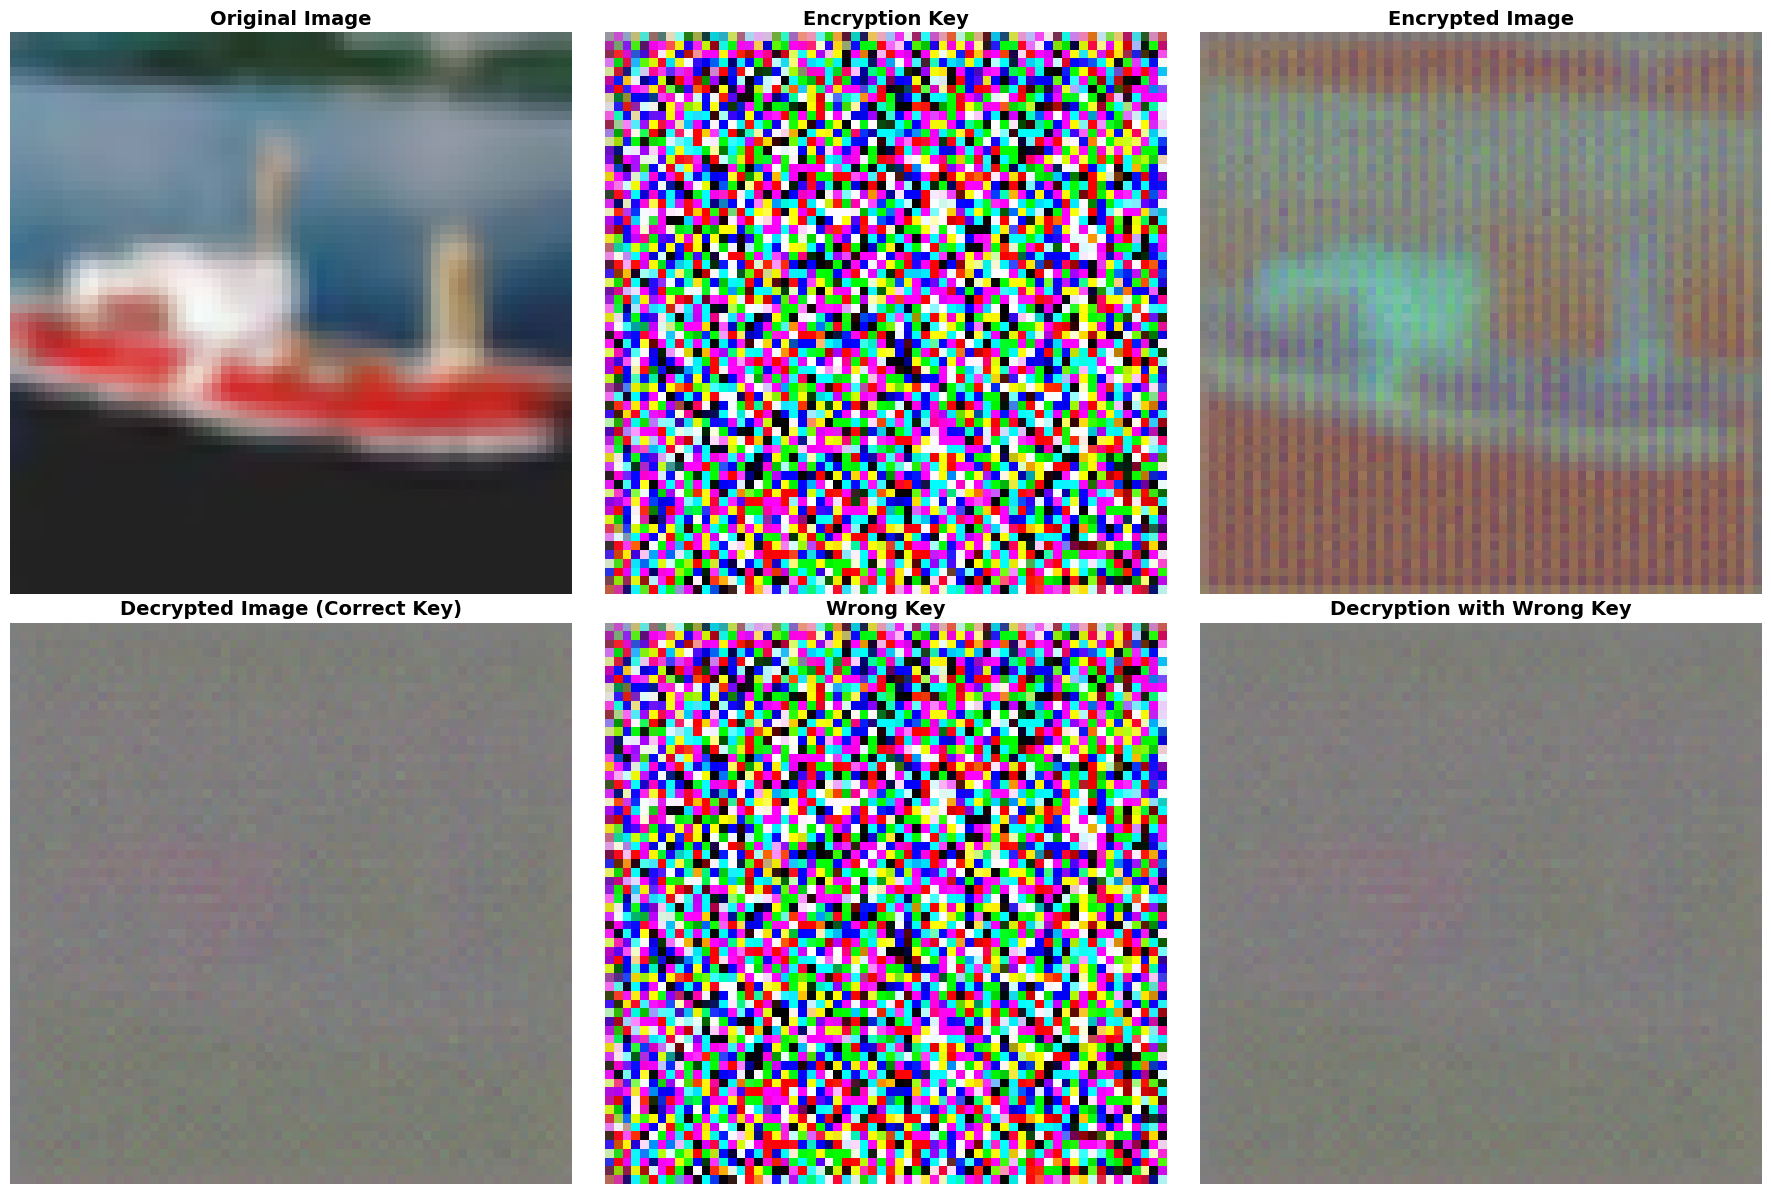

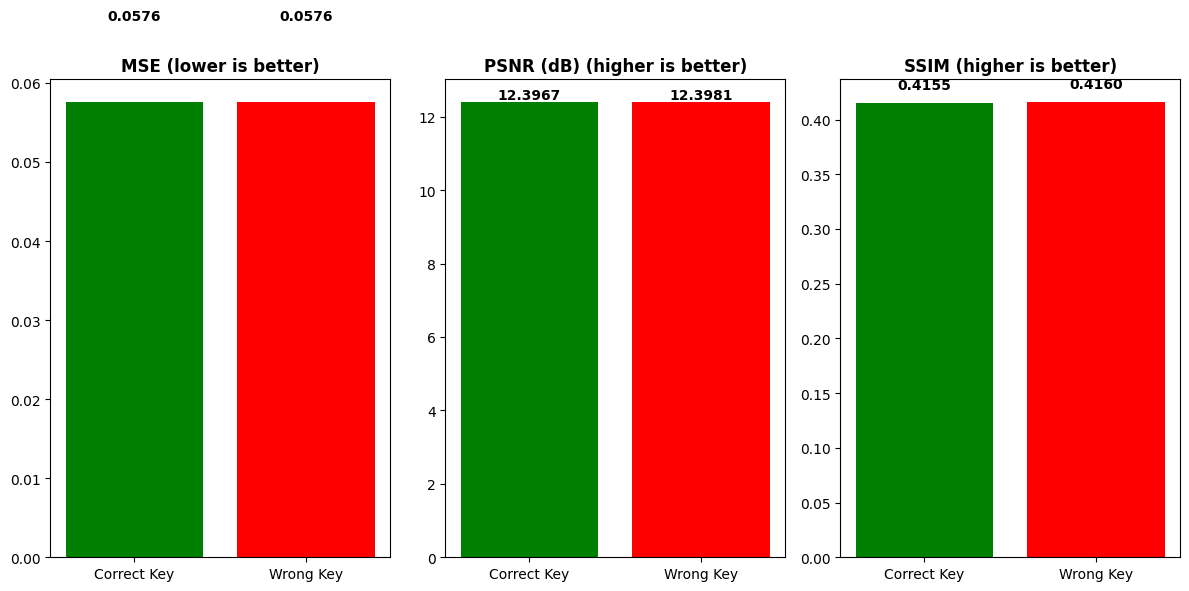


===== Encryption/Decryption Quality Metrics =====
Correct Key - MSE: 0.057587, PSNR: 12.40 dB, SSIM: 0.415496
Wrong Key   - MSE: 0.057569, PSNR: 12.40 dB, SSIM: 0.415984


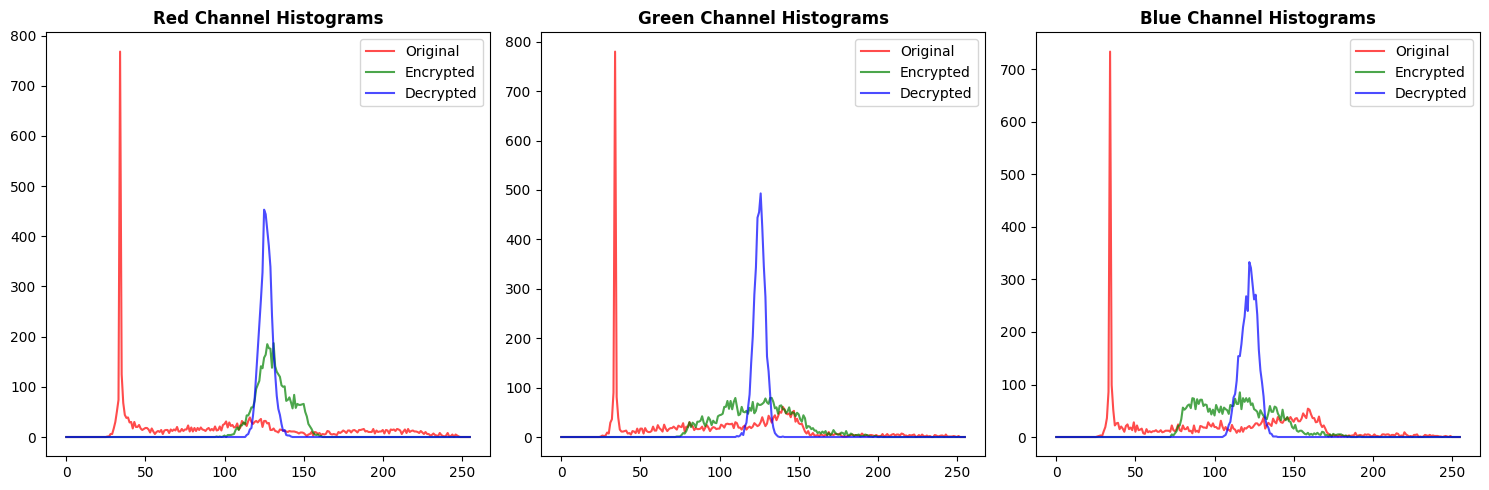

Correlation Coefficients:
Original: Horizontal=0.9903, Vertical=0.9718, Diagonal=0.9664
Encrypted: Horizontal=0.0607, Vertical=0.7246, Diagonal=0.0720
Decrypted: Horizontal=0.4015, Vertical=0.3919, Diagonal=0.4220

Information Entropy:
Original: R=6.7367, G=6.5201, B=6.6135
Encrypted: R=5.4264, G=6.5076, B=6.4054
Decrypted: R=4.0189, G=3.8650, B=4.4296

Quality Assessment:
MSE between original and decrypted: 0.057587
PSNR between original and decrypted: 12.40 dB
SSIM between original and decrypted: 0.415496

Differential Attack Analysis:
Between original and encrypted:
NPCR: 99.42% (ideal: ~99.6%)
UACI: 18.24% (ideal: ~33.4%)

Between correct and wrong key decryption:
NPCR: 40.61% (ideal: ~99.6%)
UACI: 0.17% (ideal: ~33.4%)
Animation saved to 'demo_results/encryption_process.gif'
All processes completed successfully!
Saved results and models in the current directory.


In [ ]:
def prepare_dataset(img_size=64, dataset_path=None):
    """Prepare dataset for training the models"""
    if dataset_path is None:
        # If no dataset is provided, use CIFAR-10
        print("Loading CIFAR-10 dataset...")
        (x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()

        # Resize images to the required size
        if img_size != 32:  # CIFAR-10 images are 32x32
            resized_images = []
            for img in tqdm(x_train[:10000]):  # Limit to 10k images
                resized = cv2.resize(img, (img_size, img_size))
                resized_images.append(resized)
            images = np.array(resized_images)
        else:
            images = x_train[:10000]
    else:
        # Load images from the specified directory
        print(f"Loading dataset from {dataset_path}...")
        images = []
        image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        for img_file in tqdm(image_files[:10000]):  # Limit to 10k images
            img_path = os.path.join(dataset_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)

        images = np.array(images)

    # Normalize images to [0, 1]
    images = images.astype('float32') / 255.0

    print(f"Dataset prepared: {images.shape} images")
    return images

def main():
    img_size = 64  # Size of the images
    latent_dim = 100  # Size of the noise vector for the GAN

    # Check for GPU
    print("Checking for GPU...")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"Found {len(gpus)} GPU(s)")
        for gpu in gpus:
            print(f" - {gpu.name}")

        # Set memory growth to avoid using all GPU memory at once
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
                print(f"Set memory growth for {gpu.name}")
            except RuntimeError as e:
                print(f"Error setting memory growth: {e}")
    else:
        print("No GPU found. Using CPU.")

    # Create output directories
    os.makedirs('models', exist_ok=True)
    os.makedirs('generated_images', exist_ok=True)
    os.makedirs('encryption_samples', exist_ok=True)
    os.makedirs('security_analysis', exist_ok=True)

    # Prepare the dataset
    print("Preparing dataset...")
    dataset = prepare_dataset(img_size)

    # Split dataset for training different models
    gan_train_size = int(len(dataset) * 0.7)
    encryption_train_size = len(dataset) - gan_train_size

    gan_train_data = dataset[:gan_train_size]
    encryption_train_data = dataset[gan_train_size:]

    # Initialize and train the DCGAN
    print("Initializing DCGAN...")
    dcgan = DCGAN(img_size=img_size, latent_dim=latent_dim)

    # Check if pre-trained GAN models exist
    if os.path.exists('models/generator_model.keras') and os.path.exists('models/discriminator_model.keras'):
        print("Loading pre-trained GAN models...")
        dcgan.generator = tf.keras.models.load_model('models/generator_model.keras', compile=False)
        dcgan.discriminator = tf.keras.models.load_model('models/discriminator_model.keras', compile=False)
        # Recompile to avoid warnings
        dcgan.discriminator.compile(loss='binary_crossentropy',
                                  optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
                                  metrics=['accuracy'])
        z_input = Input(shape=(dcgan.latent_dim,))
        img = dcgan.generator(z_input)
        valid = dcgan.discriminator(img)
        dcgan.combined = models.Model(z_input, valid)
        dcgan.combined.compile(loss='binary_crossentropy',
                             optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5))

        # Create symlinks in the root directory for compatibility
        if not os.path.exists('generator_model.keras'):
            os.symlink('models/generator_model.keras', 'generator_model.keras')
        if not os.path.exists('discriminator_model.keras'):
            os.symlink('models/discriminator_model.keras', 'discriminator_model.keras')
    else:
        print("Training DCGAN...")
        try:
            d_losses, g_losses = dcgan.train(gan_train_data, epochs=100, batch_size=64, save_interval=10)
            # Save models to the models directory
            dcgan.generator.save('models/generator_model.keras')
            dcgan.discriminator.save('models/discriminator_model.keras')
            # Create symlinks in the root directory for compatibility
            if not os.path.exists('generator_model.keras'):
                os.symlink('models/generator_model.keras', 'generator_model.keras')
            if not os.path.exists('discriminator_model.keras'):
                os.symlink('models/discriminator_model.keras', 'discriminator_model.keras')
        except Exception as e:
            print(f"Error during DCGAN training: {e}")
            # If training fails, we can continue with pre-trained models if they exist
            if os.path.exists('generator_model.keras'):
                print("Using existing generator model...")
                dcgan.generator = tf.keras.models.load_model('generator_model.keras', compile=False)
            else:
                print("Cannot proceed without a generator model.")
                return

    # Generate keys using the trained DCGAN
    print("Generating encryption keys...")
    num_keys = len(encryption_train_data)
    keys = dcgan.generate_keys(num_keys)

    # Initialize and train the encryption network
    print("Initializing Encryption Network...")
    encryption_net = EncryptionNetwork(img_size=img_size)
    encryption_net.compile_models()

    # Check if pre-trained encryption models exist
    if os.path.exists('models/encryption_model.keras') and os.path.exists('models/decryption_model.keras'):
        print("Loading pre-trained encryption models...")
        encryption_net.encryption_model = tf.keras.models.load_model('models/encryption_model.keras', compile=False)
        encryption_net.decryption_model = tf.keras.models.load_model('models/decryption_model.keras', compile=False)
        # Recompile to avoid warnings
        encryption_net.compile_models()
        # Create symlinks in the root directory for compatibility
        if not os.path.exists('encryption_model.keras'):
            os.symlink('models/encryption_model.keras', 'encryption_model.keras')
        if not os.path.exists('decryption_model.keras'):
            os.symlink('models/decryption_model.keras', 'decryption_model.keras')
    else:
        print("Training Encryption Network...")
        combined_losses = encryption_net.train(encryption_train_data, keys, epochs=50, batch_size=32, sample_interval=5)
        # Save models to the models directory
        encryption_net.encryption_model.save('models/encryption_model.keras')
        encryption_net.decryption_model.save('models/decryption_model.keras')
        # Create symlinks in the root directory for compatibility
        if not os.path.exists('encryption_model.keras'):
            os.symlink('models/encryption_model.keras', 'encryption_model.keras')
        if not os.path.exists('decryption_model.keras'):
            os.symlink('models/decryption_model.keras', 'decryption_model.keras')

    # Test the encryption system on a sample image
    print("Testing encryption system...")
    sample_idx = np.random.randint(0, len(encryption_train_data))
    sample_image = encryption_train_data[sample_idx]
    sample_key = keys[sample_idx]

    # Create an alternative key for security testing
    wrong_key = keys[(sample_idx + 1) % len(keys)]

    # Encrypt the sample image
    encrypted_image = encryption_net.encrypt(sample_image, sample_key)

    # Decrypt with correct key
    decrypted_image = encryption_net.decrypt(encrypted_image, sample_key)

    # Attempt decryption with wrong key
    wrong_key_decrypted = encryption_net.decrypt(encrypted_image, wrong_key)

    # Run security analysis
    print("Running security analysis...")
    security_metrics = security_analysis(sample_image, encrypted_image, decrypted_image, wrong_key_decrypted)

    # Run the demo pipeline for visualization
    print("Running demo pipeline...")
    try:
        demo_results = demo_pipeline(save_animation=True)
    except Exception as e:
        print(f"Error in demo pipeline: {e}")
        demo_results = None

    print("All processes completed successfully!")
    print("Saved results and models in the current directory.")

    return {
        'dcgan': dcgan,
        'encryption_net': encryption_net,
        'security_metrics': security_metrics,
        'demo_results': demo_results
    }

# Add a full pipeline demo function
def demo_pipeline(img_path=None, save_animation=False):
    """Demonstrate the full encryption/decryption pipeline on a single image with enhanced visualization"""
    img_size = 64

    # Load a sample image if path is provided, otherwise use a random image from CIFAR-10
    if img_path:
        # Load user image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (img_size, img_size))
        image = image.astype('float32') / 255.0
    else:
        # Use a CIFAR-10 image
        (_, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
        random_idx = np.random.randint(0, len(x_test))
        image = x_test[random_idx]
        image = cv2.resize(image, (img_size, img_size))
        image = image.astype('float32') / 255.0

    # Load pre-trained models
    if not os.path.exists('generator_model.keras'):
        print("Error: Pre-trained generator model not found. Please run training first.")
        return

    if not os.path.exists('encryption_model.keras') or not os.path.exists('decryption_model.keras'):
        print("Error: Pre-trained encryption/decryption models not found. Please run training first.")
        return

    # Load models
    generator = tf.keras.models.load_model('generator_model.keras', compile=False)
    encryption_model = tf.keras.models.load_model('encryption_model.keras', compile=False)
    decryption_model = tf.keras.models.load_model('decryption_model.keras', compile=False)

    # Generate a key
    noise = np.random.normal(0, 1, (1, 100))
    key = generator.predict(noise)
    key = 0.5 * key + 0.5  # Scale to [0, 1]
    key = key[0]

    # Generate a second key for demonstration of incorrect decryption
    noise2 = np.random.normal(0, 1, (1, 100))
    wrong_key = generator.predict(noise2)
    wrong_key = 0.5 * wrong_key + 0.5
    wrong_key = wrong_key[0]

    # Create a directory for demo results
    os.makedirs('demo_results', exist_ok=True)

    # Encrypt the image
    image_scaled = image * 2.0 - 1.0  # Scale to [-1, 1]
    key_scaled = key * 2.0 - 1.0

    encrypted_image = encryption_model.predict([np.expand_dims(image_scaled, 0), np.expand_dims(key_scaled, 0)])
    encrypted_image = (encrypted_image + 1.0) / 2.0  # Scale back to [0, 1]
    encrypted_image = encrypted_image[0]

    # Decrypt the image with correct key
    encrypted_scaled = encrypted_image * 2.0 - 1.0
    decrypted_image = decryption_model.predict([np.expand_dims(encrypted_scaled, 0), np.expand_dims(key_scaled, 0)])
    decrypted_image = (decrypted_image + 1.0) / 2.0
    decrypted_image = decrypted_image[0]

    # Decrypt with wrong key
    wrong_key_scaled = wrong_key * 2.0 - 1.0
    wrong_decrypted = decryption_model.predict([np.expand_dims(encrypted_scaled, 0), np.expand_dims(wrong_key_scaled, 0)])
    wrong_decrypted = (wrong_decrypted + 1.0) / 2.0
    wrong_decrypted = wrong_decrypted[0]

    # Display results with improved visualization
    plt.figure(figsize=(18, 12))

    # First row: Original image, encryption key, and encrypted image
    plt.subplot(2, 3, 1)
    plt.title('Original Image', fontsize=14, fontweight='bold')
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.title('Encryption Key', fontsize=14, fontweight='bold')
    plt.imshow(key)
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.title('Encrypted Image', fontsize=14, fontweight='bold')
    plt.imshow(encrypted_image)
    plt.axis('off')

    # Second row: Decrypted with correct key, wrong key, and decrypted with wrong key
    plt.subplot(2, 3, 4)
    plt.title('Decrypted Image (Correct Key)', fontsize=14, fontweight='bold')
    plt.imshow(decrypted_image)
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.title('Wrong Key', fontsize=14, fontweight='bold')
    plt.imshow(wrong_key)
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.title('Decryption with Wrong Key', fontsize=14, fontweight='bold')
    plt.imshow(wrong_decrypted)
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('demo_results/encryption_demo.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Calculate metrics
    mse_correct = mean_squared_error(image.flatten(), decrypted_image.flatten())
    psnr_correct = 10 * np.log10(1.0 / mse_correct) if mse_correct > 0 else 100
    ssim_correct = ssim(image, decrypted_image, data_range=1.0, channel_axis=2, win_size=3)

    mse_wrong = mean_squared_error(image.flatten(), wrong_decrypted.flatten())
    psnr_wrong = 10 * np.log10(1.0 / mse_wrong) if mse_wrong > 0 else 100
    ssim_wrong = ssim(image, wrong_decrypted, data_range=1.0, channel_axis=2, win_size=3)

    # Create a metrics visualization
    metrics_fig = plt.figure(figsize=(12, 6))
    metrics = [
        ('MSE (lower is better)', [mse_correct, mse_wrong]),
        ('PSNR (dB) (higher is better)', [psnr_correct, psnr_wrong]),
        ('SSIM (higher is better)', [ssim_correct, ssim_wrong])
    ]

    for i, (metric_name, values) in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        bars = plt.bar(['Correct Key', 'Wrong Key'], values, color=['green', 'red'])
        plt.title(metric_name, fontsize=12, fontweight='bold')

        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('demo_results/encryption_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print metrics in the console as well
    print("\n===== Encryption/Decryption Quality Metrics =====")
    print(f"Correct Key - MSE: {mse_correct:.6f}, PSNR: {psnr_correct:.2f} dB, SSIM: {ssim_correct:.6f}")
    print(f"Wrong Key   - MSE: {mse_wrong:.6f}, PSNR: {psnr_wrong:.2f} dB, SSIM: {ssim_wrong:.6f}")

    # Additional analysis: histogram comparison
    plt.figure(figsize=(15, 5))

    # Get histograms for each channel
    hist_orig_r = np.histogram(image[:,:,0].flatten(), bins=256, range=(0,1))[0]
    hist_enc_r = np.histogram(encrypted_image[:,:,0].flatten(), bins=256, range=(0,1))[0]
    hist_dec_r = np.histogram(decrypted_image[:,:,0].flatten(), bins=256, range=(0,1))[0]

    plt.subplot(1, 3, 1)
    plt.title('Red Channel Histograms', fontsize=12, fontweight='bold')
    plt.plot(hist_orig_r, 'r-', alpha=0.7, label='Original')
    plt.plot(hist_enc_r, 'g-', alpha=0.7, label='Encrypted')
    plt.plot(hist_dec_r, 'b-', alpha=0.7, label='Decrypted')
    plt.legend()

    hist_orig_g = np.histogram(image[:,:,1].flatten(), bins=256, range=(0,1))[0]
    hist_enc_g = np.histogram(encrypted_image[:,:,1].flatten(), bins=256, range=(0,1))[0]
    hist_dec_g = np.histogram(decrypted_image[:,:,1].flatten(), bins=256, range=(0,1))[0]

    plt.subplot(1, 3, 2)
    plt.title('Green Channel Histograms', fontsize=12, fontweight='bold')
    plt.plot(hist_orig_g, 'r-', alpha=0.7, label='Original')
    plt.plot(hist_enc_g, 'g-', alpha=0.7, label='Encrypted')
    plt.plot(hist_dec_g, 'b-', alpha=0.7, label='Decrypted')
    plt.legend()

    hist_orig_b = np.histogram(image[:,:,2].flatten(), bins=256, range=(0,1))[0]
    hist_enc_b = np.histogram(encrypted_image[:,:,2].flatten(), bins=256, range=(0,1))[0]
    hist_dec_b = np.histogram(decrypted_image[:,:,2].flatten(), bins=256, range=(0,1))[0]

    plt.subplot(1, 3, 3)
    plt.title('Blue Channel Histograms', fontsize=12, fontweight='bold')
    plt.plot(hist_orig_b, 'r-', alpha=0.7, label='Original')
    plt.plot(hist_enc_b, 'g-', alpha=0.7, label='Encrypted')
    plt.plot(hist_dec_b, 'b-', alpha=0.7, label='Decrypted')
    plt.legend()

    plt.tight_layout()
    plt.savefig('demo_results/histogram_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Perform complete security analysis
    security_metrics = security_analysis(image, encrypted_image, decrypted_image, wrong_decrypted)

    # Create animation if requested
    if save_animation:
        # Create a GIF showing the encryption and decryption process
        from matplotlib.animation import FuncAnimation

        fig, ax = plt.subplots(figsize=(6, 6))
        plt.tight_layout()

        frames = []
        # Original image
        frames.append(image)
        # Transitions to encryption (interpolate)
        for alpha in np.linspace(0, 1, 10):
            transition = (1-alpha) * image + alpha * encrypted_image
            frames.append(transition)
        # Encrypted image
        frames.append(encrypted_image)
        # Transitions to decryption (interpolate)
        for alpha in np.linspace(0, 1, 10):
            transition = (1-alpha) * encrypted_image + alpha * decrypted_image
            frames.append(transition)
        # Decrypted image
        frames.append(decrypted_image)

        # Function to update the animation
        def update(frame):
            ax.clear()
            ax.imshow(frame)
            if frame is image:
                ax.set_title('Original Image', fontsize=12, fontweight='bold')
            elif frame is encrypted_image:
                ax.set_title('Encrypted Image', fontsize=12, fontweight='bold')
            elif frame is decrypted_image:
                ax.set_title('Decrypted Image', fontsize=12, fontweight='bold')
            else:
                ax.set_title('Transition', fontsize=12, fontweight='bold')
            ax.axis('off')
            return [ax]

        ani = FuncAnimation(fig, update, frames=frames, interval=200, blit=True)
        ani.save('demo_results/encryption_process.gif', writer='pillow', dpi=80)
        plt.close()

        print("Animation saved to 'demo_results/encryption_process.gif'")

    return {
        'image': image,
        'key': key,
        'encrypted_image': encrypted_image,
        'decrypted_image': decrypted_image,
        'wrong_key': wrong_key,
        'wrong_decrypted': wrong_decrypted,
        'metrics': security_metrics
    }

# Execute only when run directly, not when imported
if __name__ == "__main__":
    main()